# Performing pseudobulking on the `InSituExperiment` object

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, InSituExperiment, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd.load_all(skip="transcripts")
xd

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

### Create `InSituExperiment` from regions

In [5]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [6]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     27bdc2e1  ++-++  0001879  Replicate 1        TMA         A-1
1     489aecae  ++-++  0001879  Replicate 1        TMA         A-2
2     0dd223d5  ++-++  0001879  Replicate 1        TMA         A-3
3     7515a66e  ++-++  0001879  Replicate 1        TMA         B-1
4     d4dd42da  ++-++  0001879  Replicate 1        TMA         B-2
5     f2f1026b  ++-++  0001879  Replicate 1        TMA         B-3

In [7]:
from insitupy.tools import generate_pseudobulk

In [8]:
psbulk = generate_pseudobulk(
    exp,
    celltype_col='cell_type_dc_sub_final',
    cells_layer=None,
    counts_layer='counts',
    mode='sum'
    )

In [11]:
psbulk

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', '591fd22a'
    layers: 'psbulk_props'

In [9]:
psbulk.layers["psbulk_props"]

array([[0.1744186 , 0.27906977, 0.59302326, ..., 0.55813953, 0.01162791,
        0.1744186 ],
       [0.00176056, 0.07570423, 0.43485915, ..., 0.24119718, 0.00880282,
        0.70774648],
       [0.01315789, 0.02631579, 0.26315789, ..., 0.07894737, 0.01315789,
        0.69736842],
       ...,
       [0.01234568, 0.33333333, 0.27160494, ..., 0.34567901, 0.14814815,
        0.40740741],
       [0.02685624, 0.41232227, 0.58609795, ..., 0.23696682, 0.02369668,
        0.49763033],
       [0.04761905, 0.28968254, 0.3015873 , ..., 0.48809524, 0.00793651,
        0.25793651]], shape=(73, 297))

## Analyze pseudobulk data

The resulting pseudobulk `AnnData` object can be used for subsequent analyses using e.g. packages like `decoupler`. A tutorial on how to analyze pseudobulk data with `decoupler` can be found [here](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html).

In [10]:
import decoupler as dc

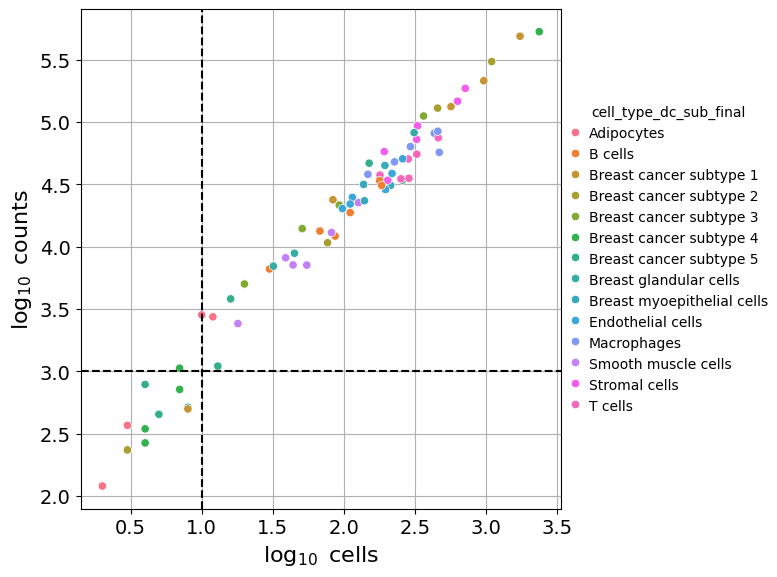

In [13]:
dc.pl.filter_samples(
    adata=psbulk,
    groupby=["cell_type_dc_sub_final"],
    min_cells=10,
    min_counts=1000,
    figsize=(8,6),
)

To continue with the analysis one requires more conditions than available in this breast cancer dataset.